# 📉 Visualizing Trend Changepoints

## 1. What is a Changepoint?
Prophet is an "additive" model, meaning it builds the forecast by adding up different parts:
$$y(t) = \text{Trend} + \text{Seasonality} + \text{Holidays}$$

The **Trend** is not just a single straight line. Prophet allows the trend to bend or change direction at specific points in time. These are called **Changepoints**.

By default:
* Prophet places potential changepoints in the first **80%** of your time series.
* It uses a mathematical penalty (regularization) to keep the trend as smooth as possible, only "bending" the line if the data strongly demands it.

## 2. Why visualize them?
The `add_changepoints_to_plot` function overlays these structural breaks onto your forecast chart.

* **Vertical Dashed Lines:** These mark the exact dates where the model decided the trend rate needed to change.
* **Red Line:** This represents the trend component itself.

**Use Case:**
* **Underfitting:** If the trend line looks straight but your data clearly curves, you might need to **increase** `changepoint_prior_scale` (make it more flexible).
* **Overfitting:** If the trend line is jittery and reacts to every small bump, you might need to **decrease** `changepoint_prior_scale` (make it stiffer).

#### 1) Importing Necessary Libraires:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet
from prophet.plot import add_changepoints_to_plot

#### 2) Loading Data:

In [2]:
df = pd.read_csv('HospitalityEmployees.csv')

In [3]:
df.head()

,Date,Employees
0,1/1/1990,1064.5
1,2/1/1990,1074.5
2,3/1/1990,1090.0
3,4/1/1990,1097.4
4,5/1/1990,1108.7


In [4]:
df.shape

(348, 2)

##### Changing Dataframe Structure to match Prophet need:

In [5]:
df.columns = ['ds', 'y']
df['ds'] = pd.to_datetime(df['ds'])
df.head()

,ds,y
0,1990-01-01,1064.5
1,1990-02-01,1074.5
2,1990-03-01,1090.0
3,1990-04-01,1097.4
4,1990-05-01,1108.7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      348 non-null    datetime64[ns]
 1   y       348 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 5.6 KB


##### Plotting Data:

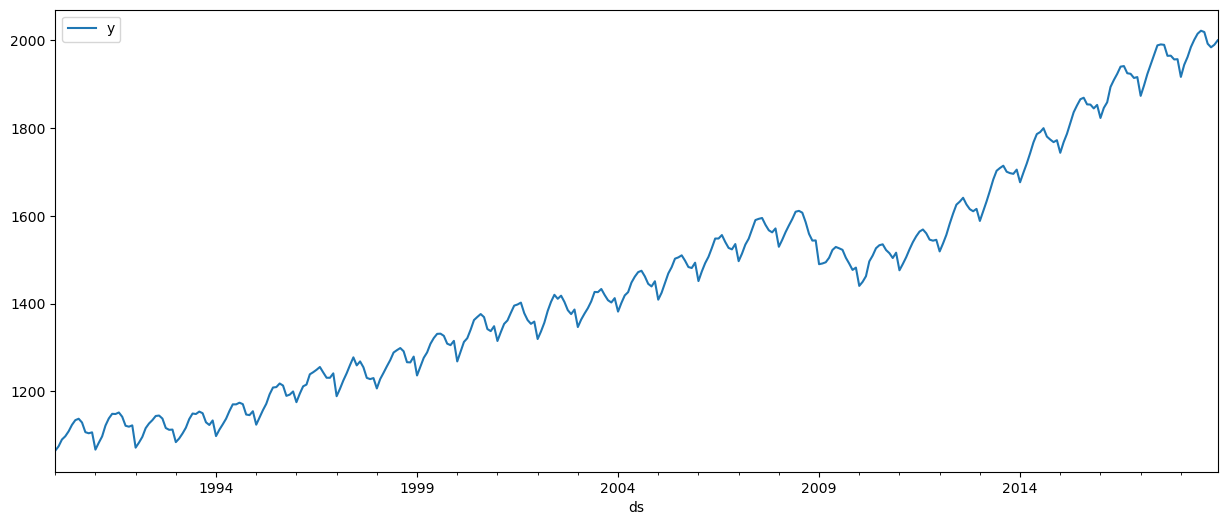

In [7]:
df.plot(x= 'ds', y= 'y', figsize= (15,6))
plt.show()

#### 3) Modelling and Forecast:

In [8]:
model = Prophet()
model.fit(df)

19:08:30 - cmdstanpy - INFO - Chain [1] start processing
19:08:31 - cmdstanpy - INFO - Chain [1] done processing


In [10]:
# Forecast:

future_df = model.make_future_dataframe(periods= 24, freq= 'MS')
forecast = model.predict(future_df)

In [11]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,1990-01-01,1106.934787,1046.370965,1072.192342,1106.934787,1106.934787,-47.569074,-47.569074,-47.569074,-47.569074,-47.569074,-47.569074,0.0,0.0,0.0,1059.365714
1,1990-02-01,1107.510794,1061.590652,1086.566324,1107.510794,1107.510794,-33.077647,-33.077647,-33.077647,-33.077647,-33.077647,-33.077647,0.0,0.0,0.0,1074.433147
2,1990-03-01,1108.031058,1076.344172,1102.232479,1108.031058,1108.031058,-18.611807,-18.611807,-18.611807,-18.611807,-18.611807,-18.611807,0.0,0.0,0.0,1089.419252
3,1990-04-01,1108.607065,1093.269644,1117.631377,1108.607065,1108.607065,-2.971026,-2.971026,-2.971026,-2.971026,-2.971026,-2.971026,0.0,0.0,0.0,1105.636040
4,1990-05-01,1109.164491,1110.529714,1135.783231,1109.164491,1109.164491,13.353255,13.353255,13.353255,13.353255,13.353255,13.353255,0.0,0.0,0.0,1122.517746


In [12]:
forecast.shape

(372, 16)

#### 4) Plotting Modelled Data:

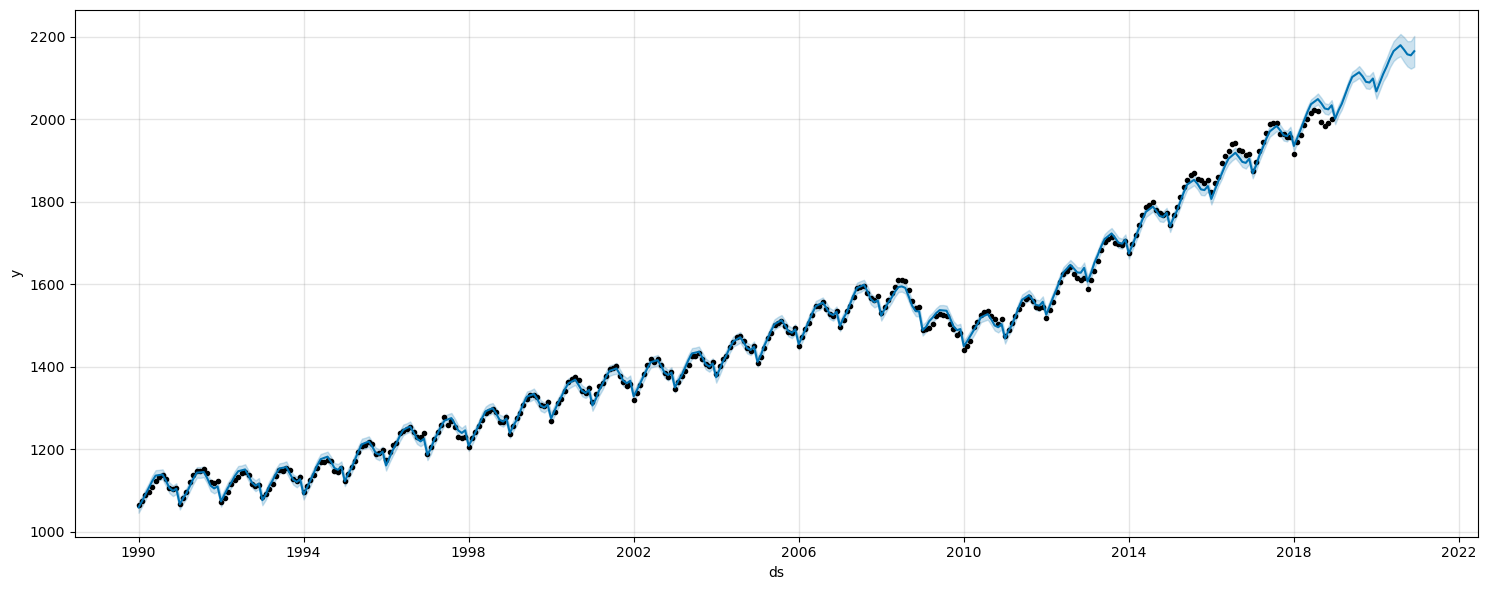

In [14]:
model.plot(forecast, figsize= (15,6))
plt.show()

##### Adding Trend Change Points to Plot:

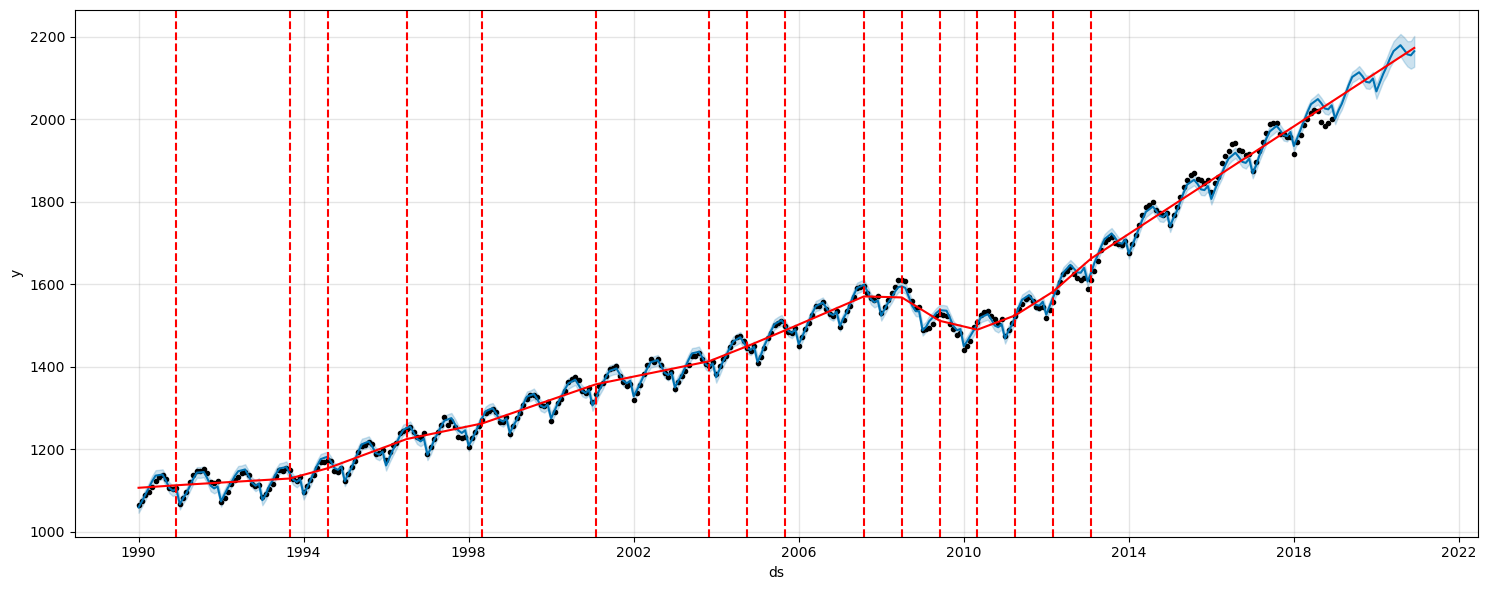

In [15]:
fig = model.plot(forecast, figsize= (15,6))
add_changepoints_to_plot(ax= fig.gca(),
                         m= model,
                        fcst= forecast)
plt.show()